In [1]:
import numpy as np
import pandas as pd
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), os.pardir)))
from pyfrechet.metric_spaces import MetricData, Sphere
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import time
from pyfrechet.metric_spaces import MetricData, Sphere
import cloudpickle
import base64
from scipy.stats import vonmises_fisher
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from joblib import Parallel, delayed

INFO: Using numpy backend


## Functions

In [3]:
def str2lambda(s):
    b = base64.b64decode(s)
    expr = cloudpickle.loads(b)
    return expr

def pb_coverage_results():
    """ Compute empirical OOB_quantile for different confidence levels. """
    coverage_df = pd.DataFrame(columns=['sample_index', 'train_size', 'kappa', 'OOB_quantile', 'forest', 'time'])
    i = 0
    for file in os.listdir(os.path.join(os.path.join(os.getcwd(), 'simulations_sphere'), 'results')):
        if (file.endswith('.npy')):# and file.split('_')[3][5:] == '100'):
            print(i)
            i+=1
            infile=open(os.path.join(os.path.join(os.getcwd(), 'simulations_sphere'), 'results/' + file), 'rb')
            result=np.load(infile, allow_pickle=True).item()
            infile.close()
        else:
            continue
        start_time = time.time()
        forest = result['forest']
        oob_quantile = np.percentile(forest.oob_errors(), (1 - np.array([0.01, 0.05, 0.1])) * 100, method='inverted_cdf')
        end_time = time.time()
        time_oob = end_time - start_time
        coverage_df = pd.concat([coverage_df, pd.DataFrame({
            'sample_index': int(file.split('_')[1][4:]),
            'train_size': int(file.split('_')[2][1:]),
            'kappa': file.split('_')[3][5:],
            'forest': [forest],
            'OOB_quantile': [oob_quantile],
        }, index=pd.RangeIndex(0, 1))], ignore_index=True)

    coverage_df['train_size'] = coverage_df['train_size'].astype('category')
    coverage_df['kappa'] = coverage_df.kappa.astype('category')
    return coverage_df


# Function defining the regression mean m_0(theta) on S^2
def m_0(theta, mu):
    """
    Compute the regression mean on S^2.
    
    Parameters:
    theta : array-like
        Angles in [0, 2pi) that parameterize the great circle.
    mu : array-like, shape (2,)
        A unit vector defining the orientation of the great circle.
    
    Returns:
    array, shape (n, 3)
        The mean directions on S^2.
    """
    theta = np.asarray(theta)
    mu = np.asarray(mu)
    assert mu.shape == (2,) and np.isclose(np.linalg.norm(mu), 1), "mu must be a unit vector in R^2"
    
    x1 = np.cos(theta)
    x2 = np.sin(theta) * mu[0]
    x3 = np.sin(theta) * mu[1]
    
    return np.column_stack((x1, x2, x3))

# Function to generate vMF samples
def simulate_data(kappa, mu, theta_samples):
    """
    Generate samples from the von Mises-Fisher distribution on S^2.
    
    Parameters:
    sample_size : int
        Number of samples to generate.
    kappa : float
        Concentration parameter of the vMF distribution.
    mu : array-like, shape (2,)
        The unit vector defining the great circle.
    
    Returns:
    dict
        A dictionary containing input angles and generated samples.
    """
    mean_directions = m_0(theta_samples, mu)  # Compute means on S^2
    
    samples = [vonmises_fisher(mean, kappa).rvs() for mean in mean_directions]
    
    return theta_samples, np.array(samples)

# Parameters
sample_sizes = [50, 100, 200, 500]  # Sample sizes
kappa_values = [100, 200]  # Concentration parameters
mu = np.array([1/np.sqrt(2), 1/np.sqrt(2)])  # Fixed unit vector in R^2

Prediction balls

In [4]:
# Define confidence levels
M = Sphere(2)
np.random.seed(1000)
sign_level = np.array([0.01, 0.05, 0.1])
# Load stored results
pb_coverage_df=pb_coverage_results()
pb_coverage_df.head()

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

,sample_index,train_size,kappa,OOB_quantile,forest,time
0,246,200,100,"[0.3177776968302442, 0.2729185771553849, 0.241...","BaggedRegressor(bootstrap_fraction=1, bootstra...",NaN
1,192,500,100,"[0.32051820879073284, 0.2537905632811303, 0.23...","BaggedRegressor(bootstrap_fraction=1, bootstra...",NaN
2,137,100,100,"[0.3366774370461913, 0.2704085121365053, 0.233...","BaggedRegressor(bootstrap_fraction=1, bootstra...",NaN
3,71,500,100,"[0.3229446467160349, 0.26211629909311746, 0.23...","BaggedRegressor(bootstrap_fraction=1, bootstra...",NaN
4,359,200,100,"[0.2947035003846111, 0.24387738118760333, 0.22...","BaggedRegressor(bootstrap_fraction=1, bootstra...",NaN


# TYPE I

In [11]:
kappas = np.array([100])

MC = 500
n_estimations = 50

zeros_init = np.zeros(shape = (n_estimations, 3))
pb_cov = np.zeros(shape = (n_estimations, 3))
conf_cov = np.zeros(shape = (n_estimations, 3))

pb_diccionario = {
    'kappa_100': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init},
    #'kappa_200': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init}
    }

In [36]:
# Obtain n_estimations estimations of Type I coverage error for each distance and N, to calculate the mean of the estimations and the sample variance
for kappa in [100, 200]:

    pb_coverage_df_kappa = pb_coverage_df[pb_coverage_df['kappa'] == str(kappa)]
    
    for N in [50, 100, 200, 500]:
        # Select the size of the training set
        pb_coverage_df_N = pb_coverage_df_kappa[pb_coverage_df_kappa['train_size'] == N]
        for estimation in range(n_estimations):
            pb_yesno = np.zeros(3)
            # Randomly select rows from the dataframe
            new_thetas = np.random.uniform(0, 2 * np.pi, size = MC).reshape(MC, 1)
            # Add a column of ones for the intercept (beta_0)
            new_thetas, new_ys = simulate_data(kappa = kappa, mu = mu, theta_samples=new_thetas)
            pb_lns = pb_coverage_df_N.sample(n=MC, replace=False)
    
            i = 0
            for j, pb_ln in pb_lns.iterrows():
                # Generate one random point to test if it belongs to the CI_region
                new_theta = new_thetas[i,:]
                #Predict the new observation
                pb_new_pred = pb_ln['forest'].predict(new_theta.reshape(-1,1))
                new_y = new_ys[i]
                new_y = MetricData(M, new_y)
                # Store the selected values
                pb_yesno = np.vstack((pb_yesno, M.d(pb_new_pred, new_y) <= pb_ln['OOB_quantile']))
                i += 1

            pb_cov[estimation, :] = pb_yesno[1:,:].sum(axis=0) / MC
            
        pb_diccionario['kappa_'+str(kappa)][str(N)] = np.copy(pb_cov)

KeyboardInterrupt: 

In [38]:
def compute_type_I_coverage(kappa, N, pb_coverage_df, MC, mu, M, n_estimations):
    pb_coverage_df_kappa = pb_coverage_df[pb_coverage_df['kappa'] == str(kappa)]
    pb_coverage_df_N = pb_coverage_df_kappa[pb_coverage_df_kappa['train_size'] == N]
    
    pb_cov = np.zeros((n_estimations, 3))  # Initialize storage

    for estimation in range(n_estimations):
        pb_yesno = np.zeros(3)
        new_thetas = np.random.uniform(0, 2 * np.pi, size=MC).reshape(MC, 1)
        new_thetas, new_ys = simulate_data(kappa=kappa, mu=mu, theta_samples=new_thetas)
        pb_lns = pb_coverage_df_N.sample(n=MC, replace=False)
        
        yesno_list = []
        for i, (_, pb_ln) in enumerate(pb_lns.iterrows()):
            new_theta = new_thetas[i, :]
            pb_new_pred = pb_ln['forest'].predict(new_theta.reshape(-1, 1))
            new_y = MetricData(M, new_ys[i])
            yesno_list.append(M.d(pb_new_pred, new_y) <= pb_ln['OOB_quantile'])

            print(i)
            
        pb_cov[estimation, :] = np.array(yesno_list).sum(axis=0) / MC


    return kappa, N, pb_cov

# Run in parallel
results = Parallel(n_jobs=8)(
    delayed(compute_type_I_coverage)(kappa, N, pb_coverage_df, MC, mu, M, n_estimations)
    for kappa in [100] for N in [50, 100, 200, 500]
)

# Store results
for kappa, N, pb_cov in results:
    pb_diccionario[f'kappa_{kappa}'][str(N)] = np.copy(pb_cov)

/Users/Diego/miniconda3/envs/pballs/lib/python3.9/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


KeyboardInterrupt: 

In [41]:
def compute_yesno(pb_ln, new_theta, new_y, M):
    """Computes whether a new observation is within the CI region."""
    pb_new_pred = pb_ln['forest'].predict(new_theta.reshape(-1, 1))
    print(M.d(pb_new_pred, new_y))
    return M.d(pb_new_pred, new_y) <= pb_ln['OOB_quantile']

def compute_type_I_coverage(kappa, N, pb_coverage_df, MC, mu, M, n_estimations):
    pb_coverage_df_kappa = pb_coverage_df[pb_coverage_df['kappa'] == str(kappa)]
    pb_coverage_df_N = pb_coverage_df_kappa[pb_coverage_df_kappa['train_size'] == N]
    
    pb_cov = np.zeros((n_estimations, 3))  # Initialize storage

    for estimation in range(n_estimations):
        new_thetas = np.random.uniform(0, 2 * np.pi, size=MC).reshape(MC, 1)
        new_thetas, new_ys = simulate_data(kappa=kappa, mu=mu, theta_samples=new_thetas)
        pb_lns = pb_coverage_df_N.sample(n=MC, replace=False)

        # Convert new_ys to MetricData
        new_ys = [MetricData(M, y) for y in new_ys]
        print(estimation)
        # Parallel computation of yes/no values
        yesno_list = Parallel(n_jobs=8)(
            delayed(compute_yesno)(pb_ln, new_thetas[i, :], new_ys[i], M)
            for i, (_, pb_ln) in enumerate(pb_lns.iterrows())
        )

        pb_cov[estimation, :] = np.array(yesno_list).sum(axis=0) / MC

    return kappa, N, pb_cov

# Run in parallel over (kappa, N) combinations
results = Parallel(n_jobs=1)(  # Only 1 outer job to avoid overloading
    delayed(compute_type_I_coverage)(kappa, N, pb_coverage_df, MC, mu, M, n_estimations)
    for kappa in [100] for N in [50, 100, 200, 500]
)

# Store results
for kappa, N, pb_cov in results:
    pb_diccionario[f'kappa_{kappa}'][str(N)] = np.copy(pb_cov)

0


INFO: Using numpy backend
INFO: Using numpy backend
INFO: Using numpy backend


[0.06839356]
[0.12261357]
[0.05806101]
[0.31641398]
[0.02581051]


INFO: Using numpy backend
INFO: Using numpy backend
INFO: Using numpy backend
INFO: Using numpy backend
INFO: Using numpy backend


[0.57736951]
[0.22013788]
[0.09069938]
[0.11730992]
[0.11286926]
[0.13637729]
[0.16977082]
[0.22128118]
[0.24147645]
[0.34015502]
[0.11855374]
[0.12944091]
[0.31858996]
[0.39113839]
[0.18414338]
[0.12617629]
[0.28517291]
[0.10624564]
[0.12324615]
[0.13692861]
[0.04867746]
[0.11255069]
[0.12189334]
[0.06722326]
[0.3849847]
[0.22641102]
[0.12711353]
[0.056561]
[0.26701222]
[0.17343851]
[0.10051485]
[0.20292628]
[0.16085534]
[0.44727677]
[0.16590232]
[0.02186492]
[0.09681449]
[0.19614368]
[0.13033307]
[0.12721276]
[0.1585849]
[0.13713402]
[0.1258189]
[0.27798014]
[0.1539695]
[0.05751275]
[0.32368745]
[0.12134584]
[0.15950002]
[0.08767024]
[0.07895311]
[0.097139]
[0.18808228]
[0.22668594]
[0.11186257]
[0.12055259]
[0.06947881]
[0.14039474]
[0.22596309]
[0.08376973]
[0.17819032]
[0.35603544]
[0.09367612]
[0.14448533]
[0.06830348]
[0.20053386]
[0.19800909]
[0.22318366]
[0.19554862]
[0.1489374]
[0.25063292]
[0.20891015]
[0.21077257]
[0.12022587]
[0.22676004]
[0.13338262]
[0.16746509]
[0.12332

KeyboardInterrupt: 

In [10]:
for kappa in [100, 200]:    
        for N in [50, 100, 200, 500]:
            print(f"kappa = {kappa}, N = {N}, mean of Type I coverage estimates: ", np.mean(pb_diccionario['kappa_'+str(kappa)][str(N)], axis = 0)) 
            print(f"kappa = {kappa}, N = {N}, standard deviation of Type I coverage estimates: ", np.sqrt(np.var(pb_diccionario['kappa_'+str(kappa)][str(N)], axis = 0))  )    

kappa = 100, N = 50, mean of Type I coverage estimates:  [0.996 0.948 0.888]
kappa = 100, N = 50, standard deviation of Type I coverage estimates:  [0. 0. 0.]
kappa = 100, N = 100, mean of Type I coverage estimates:  [0.984 0.946 0.898]
kappa = 100, N = 100, standard deviation of Type I coverage estimates:  [0. 0. 0.]
kappa = 100, N = 200, mean of Type I coverage estimates:  [0.986 0.934 0.882]
kappa = 100, N = 200, standard deviation of Type I coverage estimates:  [0. 0. 0.]
kappa = 100, N = 500, mean of Type I coverage estimates:  [0.99  0.946 0.898]
kappa = 100, N = 500, standard deviation of Type I coverage estimates:  [0. 0. 0.]


KeyError: 'kappa_200'

Prediction balls

In [10]:
# Prepare data for the DataFrame
rows = []
index = []

for kappa in [100, 200]:
    for N in [50, 100, 200, 500]:
        row = []
        means = np.mean(pb_diccionario[f'kappa_{kappa}'][str(N)], axis=0)
        stds = np.sqrt(np.var(pb_diccionario[f'kappa_{kappa}'][str(N)], axis=0))
        # Format as "mean (std)"
        formatted_values = [f"{100*means[i]:.2f} ({100*stds[i]:.2f})" for i in range(3)]
        row.extend(formatted_values)
        rows.append(row)
        index.append((f"{kappa}", f"{N}"))

# MultiIndex for rows and columns
row_index = pd.MultiIndex.from_tuples(index, names=["kappa", "N"])
col_index = pd.MultiIndex.from_product(
    [["0.01", "0.05", "0.1"]],
    names=[r"Significance Level"]
)

# Create the DataFrame
df = pd.DataFrame(rows, index=row_index, columns=col_index)

# Display the DataFrame
df

Significance Level          0.01          0.05           0.1
sigma N                                                     
0.1   100           98.32 (0.50)  94.52 (0.91)  89.66 (1.30)
      500           98.91 (0.45)  95.21 (0.95)  90.37 (1.24)
      1500          99.04 (0.37)  95.03 (0.95)  90.15 (1.34)
0.5   100           97.91 (0.57)  93.76 (1.04)  88.77 (1.37)
      500           98.83 (0.49)  94.86 (0.86)  89.79 (1.24)
      1500          99.00 (0.43)  94.84 (1.04)  89.76 (1.32)

In [11]:
import pandas as pd
def format_cell(value):
    mean, std = value.split(" ")
    mean = f"{float(mean):.2f}"
    std = std.strip("()")
    std = f"({float(std):.2f})"
    return f"{mean} {std}"

# Apply formatting to all cells
df = df.applymap(format_cell)

latex = df.to_latex(index=True, multirow=True, multicolumn=True, multicolumn_format='c', bold_rows=True, float_format= "%.3f" , caption='Type I error', label='tab:typeIerrorcoverage')

/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_25111/2260981167.py:10: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(format_cell)


In [12]:
print(latex)

\begin{table}
\caption{Type I error coverage for different distances, degrees of freedom and sample sizes}
\label{tab:typeIerrorcoverage}
\begin{tabular}{lllll}
\toprule
 & Significance Level & ('0.01',) & ('0.05',) & ('0.1',) \\
sigma & N &  &  &  \\
\midrule
\multirow[t]{3}{*}{\textbf{0.1}} & \textbf{100} & 98.32 (0.50) & 94.52 (0.91) & 89.66 (1.30) \\
\textbf{} & \textbf{500} & 98.91 (0.45) & 95.21 (0.95) & 90.37 (1.24) \\
\textbf{} & \textbf{1500} & 99.04 (0.37) & 95.03 (0.95) & 90.15 (1.34) \\
\cline{1-5}
\multirow[t]{3}{*}{\textbf{0.5}} & \textbf{100} & 97.91 (0.57) & 93.76 (1.04) & 88.77 (1.37) \\
\textbf{} & \textbf{500} & 98.83 (0.49) & 94.86 (0.86) & 89.79 (1.24) \\
\textbf{} & \textbf{1500} & 99.00 (0.43) & 94.84 (1.04) & 89.76 (1.32) \\
\cline{1-5}
\bottomrule
\end{tabular}
\end{table}



# TYPE II

In [37]:
pb_coverage_df['II_coverage'] = [[0, 0, 0] for _ in range(len(pb_coverage_df))]
MC = 500

np.random.seed(1000)

#Calculate coverage for every dataset L_n (Type II):
for i, ln in pb_coverage_df.iterrows():
    #Generate observations to estimate the probability
    theta_samples = np.random.uniform(0, 2 * np.pi, size = MC).reshape(-1,1)
    new_X, new_y = simulate_data(kappa = float(ln['kappa']), theta_samples = theta_samples, mu = mu)
    
    new_pred = ln['forest'].predict(new_X.reshape(-1,1))

    pb_coverage_df.at[i, 'II_coverage'] = np.sum(M.d(MetricData(M, new_y), new_pred) <= np.tile(ln['OOB_quantile'], (MC, 1)), axis = 0) / MC

KeyboardInterrupt: 

In [42]:
#Calculate coverage for every dataset L_n (Type II):
for i, ln in pb_coverage_df.iterrows():
    #Generate observations to estimate the probability
    theta_samples = np.random.uniform(0, 2 * np.pi, size = MC).reshape(-1,1)
    new_X, new_y = simulate_data(kappa = float(ln['kappa']), theta_samples = theta_samples, mu = mu)
    
    new_pred = ln['forest'].predict(new_X.reshape(-1,1))
    print(i)
    pb_coverage_df.at[i, 'II_coverage'] = np.sum(M.d(MetricData(M, new_y), new_pred) <= np.tile(ln['OOB_quantile'], (MC, 1)), axis = 0) / MC

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

KeyboardInterrupt: 

In [5]:
from joblib import Parallel, delayed

pb_coverage_df['II_coverage'] = [[0, 0, 0] for _ in range(len(pb_coverage_df))]
MC = 500

np.random.seed(1000)

def compute_coverage(i, ln, MC, mu):
    # Generate observations to estimate the probability
    theta_samples = np.random.uniform(0, 2 * np.pi, size=MC).reshape(-1, 1)
    new_X, new_y = simulate_data(kappa=float(ln['kappa']), theta_samples=theta_samples, mu=mu)

    new_pred = ln['forest'].predict(new_X.reshape(-1, 1))
    coverage = np.sum(M.d(MetricData(M, new_y), new_pred) <= np.tile(ln['OOB_quantile'], (MC, 1)), axis=0) / MC
    print(i)
    return i, coverage

# Run in parallel
results = Parallel(n_jobs=8)(delayed(compute_coverage)(i, ln, MC, mu) for i, ln in pb_coverage_df.iterrows())

# Store results
for i, coverage in results:
    pb_coverage_df.at[i, 'II_coverage'] = coverage

INFO: Using numpy backend
INFO: Using numpy backend
INFO: Using numpy backend
INFO: Using numpy backend
INFO: Using numpy backend
INFO: Using numpy backend
INFO: Using numpy backend
INFO: Using numpy backend


0
2
1
5
4
7
3
6
8
9
11
13
12
10
16
14
15
18
17
19
21
20
23
25
27
22
26
24
29
30
28
31
32
33
34
36
37
35
39
38
41
40
42
43
46
47
44
45
49
51
50
48
53
52
54
56
55
57
59
58
61
60
63
64
65
67
66
62
68
71
69
70
72
75
74
73
76
78
77
80
81
82
83
79
84
86
85
87
88
90
91
89
92
93
95
94
97
98
99
96
103
102
100
101
105
107
104
106
110
112
108
111
109
115
113
114
118
116
119
117
120
122
121
123
124
125
126
128
129
127
132
130
134
131
133
136
135
138
137
139
140
141
143
142
144
145
147
146
149
148
150
152
153
154
151
155
158
157
160
159
156
161
163
162
167
168
165
164
169
166
170
171
172
174
173
178
176
177
175
179
180
181
183
182
184
188
187
185
186
189
190
191
193
194
192
196
197
195
198
200
202
201
199
203
205
206
204
209
207
210
211
208
214
213
215
212
217
216
220
219
218
222
221
224
223
225
227
226
230
228
229
232
231
233
234
237
235
238
236
240
239
243
241
245
242
244
247
246
249
248
250
254
252
251
253
255
258
256
260
259
257
262
261
263
266
265
264
267
268
270
269
272
273
271
276
274
275
27

In [6]:
ii_pb_coverage_df_alpha_01 = pb_coverage_df.copy()
ii_pb_coverage_df_alpha_05 = pb_coverage_df.copy()
ii_pb_coverage_df_alpha_1  = pb_coverage_df.copy()

ii_pb_coverage_df_alpha_01['II_coverage'] = pb_coverage_df['II_coverage'].apply(lambda x: x[0])
ii_pb_coverage_df_alpha_01['OOB_quantile'] = pb_coverage_df['OOB_quantile'].apply(lambda x: x[0])

ii_pb_coverage_df_alpha_05['II_coverage'] = pb_coverage_df['II_coverage'].apply(lambda x: x[1])
ii_pb_coverage_df_alpha_05['OOB_quantile'] = pb_coverage_df['OOB_quantile'].apply(lambda x: x[1])

ii_pb_coverage_df_alpha_1['II_coverage'] = pb_coverage_df['II_coverage'].apply(lambda x: x[2])
ii_pb_coverage_df_alpha_1['OOB_quantile'] = pb_coverage_df['OOB_quantile'].apply(lambda x: x[2])

ii_pb_coverage_df_alpha_01.head()
ii_pb_coverage_df_alpha_05.head()
ii_pb_coverage_df_alpha_1.head()

,sample_index,train_size,kappa,OOB_quantile,forest,time,II_coverage
0,246,200,100,0.241061,"BaggedRegressor(bootstrap_fraction=1, bootstra...",NaN,0.924
1,192,500,100,0.235017,"BaggedRegressor(bootstrap_fraction=1, bootstra...",NaN,0.922
2,137,100,100,0.233289,"BaggedRegressor(bootstrap_fraction=1, bootstra...",NaN,0.888
3,71,500,100,0.237899,"BaggedRegressor(bootstrap_fraction=1, bootstra...",NaN,0.906
4,359,200,100,0.225329,"BaggedRegressor(bootstrap_fraction=1, bootstra...",NaN,0.856


/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_2934/3002547001.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(boxplot_data, labels = ['50', '100', '200', '500'], notch=False, boxprops=boxprops, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False)


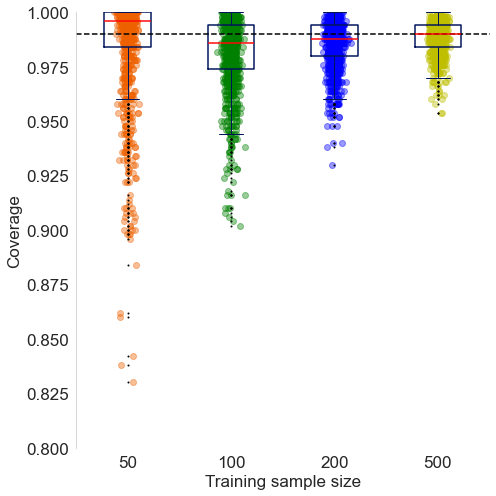

/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_2934/3002547001.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(boxplot_data, labels = ['50', '100', '200', '500'], notch=False, boxprops=boxprops, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False)


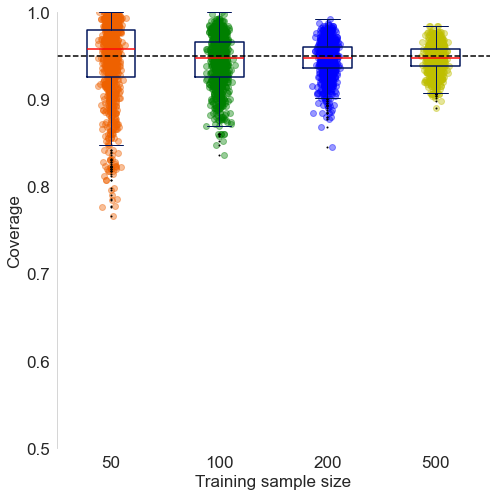

/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_2934/3002547001.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(boxplot_data, labels = ['50', '100', '200', '500'], notch=False, boxprops=boxprops, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False)


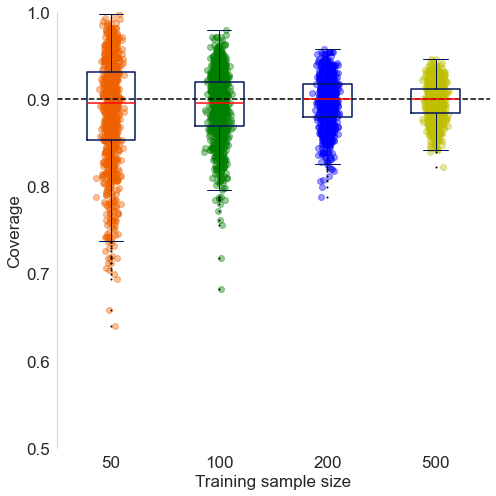

In [12]:
##### Set style options here #####
boxprops = dict(linestyle='-', linewidth=1.5, color='#00145A')
flierprops = dict(marker='o', markersize=1, linestyle='none')
whiskerprops = dict(color='#00145A')
capprops = dict(color='#00145A')
medianprops = dict(linewidth=1.5, linestyle='-', color='#ff0808')

for data, alpha_level in zip([ii_pb_coverage_df_alpha_01, ii_pb_coverage_df_alpha_05, ii_pb_coverage_df_alpha_1], [0.01, 0.05, 0.1]):
    fig = plt.figure(facecolor="white", figsize=(7, 7))
    ax = fig.add_subplot(111)

    #Note: when simulations are finalized, tehre should not be any need to select the first 40 (it is done because colukn had different lengths)
    data_50 = data[data['train_size'] == 50]
    data_100 = data[data['train_size'] == 100]
    data_200 = data[data['train_size'] == 200]
    data_500 = data[data['train_size'] == 500]

    boxplot_data = pd.DataFrame({
        '50': data_50['II_coverage'].values,
        '100': data_100['II_coverage'].values,
        '200': data_200['II_coverage'].values,
        '500': data_500['II_coverage'].values,
    })

    sns.set_style("whitegrid")  # "white","dark","darkgrid","ticks"

    #sns.boxplot(data = data, x='train_size', y='II_coverage',
               # flierprops={"marker": "x"}, dodge=True, showmeans=True, meanprops={'marker':'o','markerfacecolor':'white','markeredgecolor':'white','markersize':'4'})

    ax.boxplot(boxplot_data, labels = ['50', '100', '200', '500'], notch=False, boxprops=boxprops, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False) 
    
    vals, names, xs = [],[],[]
    for i, col in enumerate(boxplot_data.columns):
        vals.append(boxplot_data[col].values)
        names.append(col)
        xs.append(np.random.normal(i + 1, 0.04, boxplot_data[col].values.shape[0]))  # adds jitter to the data points - can be adjusted
    palette = ['#ee6100', 'g', 'b', 'y']
    for x, val, c in zip(xs, vals, palette):
        ax.scatter(x, val, alpha=0.4, color=c)
    sns.despine(bottom=True) # removes right and top axis lines

    #plt.legend(bbox_to_anchor=(0.31, 1.06), loc=2, borderaxespad=0., framealpha=1, facecolor ='white', frameon=True)
    if alpha_level == 0.01:
        ax.set_ylim(0.8, 1)
    else:
        ax.set_ylim(0.5, 1)
        
    ax.set_xlabel('Training sample size', fontsize=17)
    ax.set_ylabel('Coverage', fontsize=17)
    ax.tick_params(labelsize=17)
    ax.axhline(y=1-alpha_level, color='black', linestyle='dashed')
    ax.grid(False)
    fig.tight_layout()
    filename = os.path.join(os.getcwd(),'simulations_sphere/pb_kappa_II_coverage_' + str(alpha_level)[2:] + '.pdf')
    fig.savefig(filename, bbox_inches = 'tight', format='pdf', transparent=True)
    plt.show()

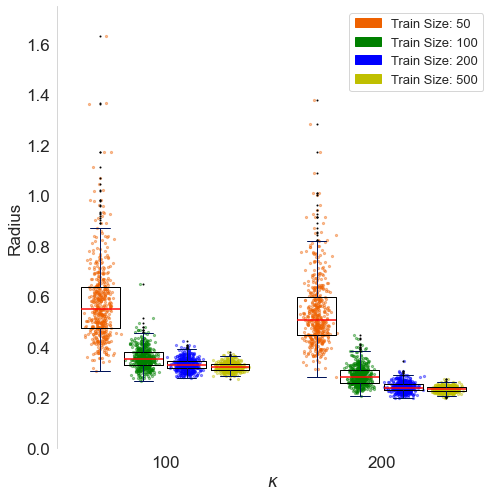

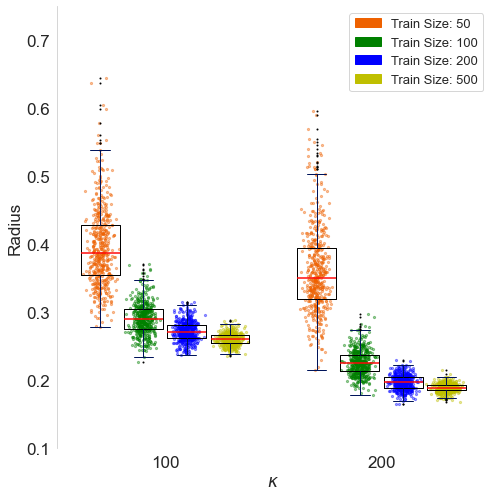

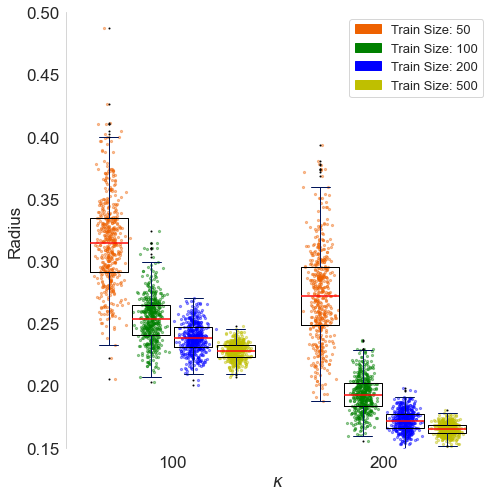

In [12]:
for data, alpha_level in zip(
    [ii_pb_coverage_df_alpha_01, ii_pb_coverage_df_alpha_05, ii_pb_coverage_df_alpha_1], 
    [0.01, 0.05, 0.1]):
    if alpha_level == 0.01:
        coverage_df = ii_pb_coverage_df_alpha_01
    elif alpha_level == 0.05:
        coverage_df = ii_pb_coverage_df_alpha_05
    else:
        coverage_df = ii_pb_coverage_df_alpha_1

    # Extract unique train sizes and degrees of freedom
    train_sizes = sorted(coverage_df['train_size'].unique())
    kappas = sorted(coverage_df['kappa'].unique())
    # Prepare the data for boxplots
    grouped_data = [
        [coverage_df.loc[(coverage_df['kappa'] == kappa) & (coverage_df['train_size'] == N), 'OOB_quantile']
            for N in train_sizes]
        for kappa in kappas ]

    # Plotting
    fig = plt.figure(facecolor="white", figsize=(7, 7))
    ax = fig.add_subplot(111)

    palette = ['#ee6100', 'g', 'b', 'y']  # Generate unique colors

    for i, group in enumerate(grouped_data):
        #In this loop, select the degrees of freedom
        base_position = 1 + i * (len(train_sizes) + 1)  # spacing between groups

        for j, ts_data in enumerate(group):
            #In this loop, select the train sizes. ts_data is the dataset for train size and df
            pos = base_position + j

            #ax.boxplot(ts_data, positions=[pos], widths=1, patch_artist=True, 
            #            boxprops=dict(facecolor=palette[j], alpha=.9),
            #            flierprops={'marker': 'x', 'color': 'red'})
            ax.boxplot(ts_data, positions=[pos], widths = .9, notch=False, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False) 

    
            palette = ['#ee6100', 'g', 'b', 'y']
            for x, val in zip(np.random.normal(pos, 0.14, ts_data.shape[0]), ts_data):
                ax.scatter(x, val, alpha=0.4, color = palette[j], s = 5)


    sns.despine(bottom=True) # removes right and top axis lines

    # Formatting
    ax.set_xticks(
        ticks=[1 + i * (len(train_sizes) + 1) + (len(train_sizes) - 1) / 2 for i in range(len(kappas))],
        labels=kappas
    )
    ax.set_xlim(0, len(kappas) * (len(train_sizes) + 1))
    if alpha_level == 0.01:
        ax.set_ylim(0, 1.75)
    elif alpha_level == 0.05:
        ax.set_ylim(0.1, 0.75)
    else:
        ax.set_ylim(0.15, 0.5)
        
    ax.set_xlabel(r'$\kappa$', fontsize=17)
    ax.set_ylabel('Radius', fontsize=17)
    ax.tick_params(axis='x', labelsize=17)
    ax.tick_params(axis='y', labelsize=17)
    legend_handles = [
        mpatches.Patch(color=palette[j], label=f'Train Size: {train_sizes[j]}') 
        for j in range(len(train_sizes))
    ]
    ax.legend(handles=legend_handles, loc='upper right', fontsize=13)
    ax.grid(False)
    fig.tight_layout()
    
    filename = os.path.join(os.getcwd(), 'simulations_sphere/pb_sphere_radius_vs_kappa' + str(alpha_level)[2:] + '.pdf')
    fig.savefig(filename, bbox_inches = 'tight', format='pdf', transparent=True)
    plt.show()

# TYPE III

In [25]:
MC = 500
n_estimations = 100

zeros_init = np.zeros(shape = (n_estimations, 3))
pb_cov = np.zeros(shape = (n_estimations, 3))
conf_cov = np.zeros(shape = (n_estimations, 3))

pb_diccionario_iii = {
    'kappa_100': {'50': zeros_init, '100': zeros_init, '500': zeros_init},
    'kappa_200': {'50': zeros_init, '100': zeros_init, '500': zeros_init}
    }

# Obtain n_estimations estimations of Type III coverage error for each distance and N, to calculate the mean of the estimations and the sample variance
for kappa in [100, 200]:
    pb_coverage_df_kappa = pb_coverage_df[pb_coverage_df['kappa'] == str(kappa)]
    for N in [50, 100, 200, 500]:
        # Select the size of the training set
        pb_coverage_df_N = pb_coverage_df_kappa[pb_coverage_df_kappa['train_size'] == N]
        for estimation in range(n_estimations):
            pb_yesno = np.zeros(3)

            theta = np.repeat(3*np.pi/2, MC)
            theta, new_ys = simulate_data(kappa = kappa, mu = mu, theta_samples = theta)
            pb_lns = pb_coverage_df_N.sample(n=MC, replace=False)
            
            i = 0
            for j, pb_ln in pb_lns.iterrows():
                # Retrieve the data           
                new_y = MetricData(M, new_ys[i])
                new_X = new_X_design[0,:].reshape(-1, 1)
                pb_new_pred = pb_ln['forest'].predict(new_X)
                # Store the selected values
                pb_yesno = np.vstack((pb_yesno, M.d(pb_new_pred - new_y) <= pb_ln['OOB_quantile']))

                i += 1
            pb_cov[estimation, :] = pb_yesno[1:,:].sum(axis=0) / MC

        pb_diccionario_iii['kappa_'+str(kappa)][str(N)] = np.copy(pb_cov)

In [4]:
MC = 500
n_estimations = 5

zeros_init = np.zeros(shape = (n_estimations, 3))
pb_cov = np.zeros(shape = (n_estimations, 3))
conf_cov = np.zeros(shape = (n_estimations, 3))

pb_diccionario_iii = {
    'kappa_100': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init},
    # 'kappa_200': {'50': zeros_init, '200': zeros_init, '100': zeros_init, '500': zeros_init}
    }

In [13]:
from joblib import Parallel, delayed

# Initialize IV_coverage column
np.random.seed(1000)
pb_coverage_df['IV_coverage'] = [[0, 0, 0] for _ in range(len(pb_coverage_df))]
MC = 500
n_estimations = 3
def compute_yesno_iii(pb_ln, new_y):
    """Computes whether a single new observation is within the confidence interval."""
    new_pred = np.array([pb_ln['forest'].predict(np.array([3*np.pi/4]).reshape(-1, 1))])
    return M.d(new_pred, new_y.data) <= pb_ln['OOB_quantile']

def compute_IV_coverage(kappa, N, pb_coverage_df, MC, n_estimations):
    pb_coverage_df_kappa = pb_coverage_df[pb_coverage_df['kappa'] == str(kappa)]
    pb_coverage_df_N = pb_coverage_df_kappa[pb_coverage_df_kappa['train_size'] == N]
    
    pb_cov_iii = np.zeros((n_estimations, 3))  # Initialize storage

    for estimation in range(n_estimations):
        # Generate new response values
        new_y = simulate_data(kappa=kappa, mu=mu, theta_samples=3*np.pi/4)[1]
        new_y = MetricData(M, new_y[:,0])
        pb_lns = pb_coverage_df_N.sample(n=MC, replace=False)
        # Compute coverage in parallel
        yesno_list = Parallel(n_jobs=8)(
            delayed(compute_yesno_iii)(pb_ln, new_y) 
            for i, (_, pb_ln) in enumerate(pb_lns.iterrows())
        )

        pb_cov_iii[estimation, :] = np.array(yesno_list).sum(axis=0) / MC
    return kappa, N, np.mean(pb_cov_iii, axis=0)

# Run in parallel over rows
results = Parallel(n_jobs=1)(
    delayed(compute_IV_coverage)(kappa, N, pb_coverage_df, MC, n_estimations)
    for kappa in [100] for N in [50, 100, 200, 500]
)

for kappa, N, pb_cov_iii in results:
    pb_diccionario_iii[f'kappa_{kappa}'][str(N)] = np.mean(pb_cov_iii, axis=0)

NameError: name 'pb_diccionario_iii' is not defined

In [14]:
results

[(100, 50, array([0.99933333, 0.99666667, 0.984     ])),
 (100, 100, array([0.97866667, 0.91933333, 0.83866667])),
 (100, 200, array([0.98866667, 0.93      , 0.832     ])),
 (100, 500, array([1.        , 1.        , 0.99533333]))]

In [118]:
for estimation in range(n_estimations):
    print(estimation)

0
1
2


In [15]:
np.random.seed(10)
print(np.random.uniform(0,1, 1))
print(np.random.uniform(0,1, 2))

[0.77132064]
[0.02075195 0.63364823]


In [115]:
pb_cov_iii

array([[1.  , 0.88, 0.71],
       [0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  ]])

In [110]:
oob_quantiles = pb_coverage_df[pb_coverage_df['train_size'] == 500]['OOB_quantile'].values
oob_quantiles_array = np.array(oob_quantiles.tolist())
oob_quantiles_array[:,2].mean()

0.22788666051118486

In [114]:
pb_diccionario_iii

{'kappa_100': {'50': array([[1.  , 0.99, 0.91],
         [0.  , 0.  , 0.  ],
         [0.  , 0.  , 0.  ]]),
  '100': array([[1.  , 0.99, 0.98],
         [0.  , 0.  , 0.  ],
         [0.  , 0.  , 0.  ]]),
  '200': array([[1., 1., 1.],
         [0., 0., 0.],
         [0., 0., 0.]]),
  '500': array([[1.  , 0.88, 0.71],
         [0.  , 0.  , 0.  ],
         [0.  , 0.  , 0.  ]])}}

In [78]:
for kappa in [100]:    
    for N in [50, 100, 200, 500]:
        print(f"kappa = {kappa}, N = {N}, mean of Type III coverage estimates: ", np.mean(pb_diccionario_iii['kappa_'+str(kappa)][str(N)], axis = 0)) 
        print(f"kappa = {kappa}, N = {N}, standard deviation of Type III coverage estimates: ", np.sqrt(np.var(pb_diccionario_iii['kappa_'+str(kappa)][str(N)], axis = 0))  )   

kappa = 100, N = 50, mean of Type III coverage estimates:  [0.986 0.958 0.878]
kappa = 100, N = 50, standard deviation of Type III coverage estimates:  [0. 0. 0.]
kappa = 100, N = 100, mean of Type III coverage estimates:  [0.998 0.99  0.98 ]
kappa = 100, N = 100, standard deviation of Type III coverage estimates:  [0. 0. 0.]
kappa = 100, N = 200, mean of Type III coverage estimates:  [1. 1. 1.]
kappa = 100, N = 200, standard deviation of Type III coverage estimates:  [0. 0. 0.]
kappa = 100, N = 500, mean of Type III coverage estimates:  [0.994 0.89  0.678]
kappa = 100, N = 500, standard deviation of Type III coverage estimates:  [0. 0. 0.]


In [51]:
pb_diccionario

{'kappa_100': {'50': array([[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0

In [27]:
# Prepare data for the DataFrame
rows = []
index = []

for kappa in [100, 200]:
    for N in [50, 100, 200, 500]:
        row = []
        means = np.mean(pb_diccionario_iii[f'kappa_{kappa}'][str(N)], axis=0)
        stds = np.sqrt(np.var(pb_diccionario_iii[f'kappa_{kappa}'][str(N)], axis=0))
        # Format as "mean (std)"
        formatted_values = [f"{100*means[i]:.2f} ({100*stds[i]:.2f})" for i in range(3)]
        row.extend(formatted_values)
        rows.append(row)
        index.append((f"{kappa}", f"{N}"))

# MultiIndex for rows and columns
row_index = pd.MultiIndex.from_tuples(index, names=["kappa", "N"])
col_index = pd.MultiIndex.from_product(
    [["0.01", "0.05", "0.1"]],
    names=["Significance Level"]
)

# Create the DataFrame
pb_df_iii = pd.DataFrame(rows, index=row_index, columns=col_index)
# Display the DataFrame
pb_df_iii

Significance Level          0.01          0.05           0.1
sigma N                                                     
0.1   100           99.98 (0.06)  99.55 (0.27)  98.27 (0.48)
      500           99.90 (0.14)  98.48 (0.49)  95.49 (0.79)
      1500          99.54 (0.29)  96.76 (0.77)  92.58 (1.17)
0.5   100           98.78 (0.44)  95.55 (0.85)  91.28 (1.11)
      500           99.03 (0.40)  95.43 (0.95)  90.76 (1.46)
      1500          98.99 (0.37)  95.28 (0.96)  90.33 (1.10)

In [28]:
# Apply formatting to all cells
pb_latex_iii= pb_df_iii.applymap(format_cell)

pb_latex_iii = pb_latex_iii.to_latex(index=True, multirow=True, multicolumn=True, multicolumn_format='c', bold_rows=True, float_format= "%.3f" , caption=r'Type I error coverage for differentvalues of $\sigma$ and sample sizes', label='tab:typeIerrorcoverage')
print(pb_latex_iii)

\begin{table}
\caption{Type I error coverage for differentvalues of $\sigma$ and sample sizes}
\label{tab:typeIerrorcoverage}
\begin{tabular}{lllll}
\toprule
 & Significance Level & ('0.01',) & ('0.05',) & ('0.1',) \\
sigma & N &  &  &  \\
\midrule
\multirow[t]{3}{*}{\textbf{0.1}} & \textbf{100} & 99.98 (0.06) & 99.55 (0.27) & 98.27 (0.48) \\
\textbf{} & \textbf{500} & 99.90 (0.14) & 98.48 (0.49) & 95.49 (0.79) \\
\textbf{} & \textbf{1500} & 99.54 (0.29) & 96.76 (0.77) & 92.58 (1.17) \\
\cline{1-5}
\multirow[t]{3}{*}{\textbf{0.5}} & \textbf{100} & 98.78 (0.44) & 95.55 (0.85) & 91.28 (1.11) \\
\textbf{} & \textbf{500} & 99.03 (0.40) & 95.43 (0.95) & 90.76 (1.46) \\
\textbf{} & \textbf{1500} & 98.99 (0.37) & 95.28 (0.96) & 90.33 (1.10) \\
\cline{1-5}
\bottomrule
\end{tabular}
\end{table}



/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_25111/2774234259.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  pb_latex_iii= pb_df_iii.applymap(format_cell)


In [29]:
for kappa in [100, 200]:    
    for N in [50, 100, 200, 500]:
        print(f"kappa = {kappa}, N = {N}, mean of Type III coverage estimates: ", np.mean(conf_diccionario_iii['kappa_'+str(kappa)][str(N)], axis = 0)) 
        print(f"kappa = {kappa}, N = {N}, standard deviation of Type III coverage estimates: ", np.sqrt(np.var(conf_diccionario_iii['kappa_'+str(kappa)][str(N)], axis = 0))  )   

sigma = 0.1, N = 100, mean of Type III coverage estimates:  [0.9987 0.9944 0.9755]
sigma = 0.1, N = 100, standard deviation of Type III coverage estimates:  [0.00107238 0.00272764 0.00470213]
sigma = 0.1, N = 500, mean of Type III coverage estimates:  [0.99972 0.99306 0.97428]
sigma = 0.1, N = 500, standard deviation of Type III coverage estimates:  [0.000801   0.0034578  0.00647469]
sigma = 0.1, N = 1500, mean of Type III coverage estimates:  [0.99704 0.97556 0.939  ]
sigma = 0.1, N = 1500, standard deviation of Type III coverage estimates:  [0.00221775 0.0065396  0.01142454]
sigma = 0.5, N = 100, mean of Type III coverage estimates:  [0.98792 0.95942 0.9096 ]
sigma = 0.5, N = 100, standard deviation of Type III coverage estimates:  [0.00482427 0.00877403 0.0129244 ]
sigma = 0.5, N = 500, mean of Type III coverage estimates:  [0.9909  0.9561  0.90838]
sigma = 0.5, N = 500, standard deviation of Type III coverage estimates:  [0.00413159 0.00965971 0.0134928 ]
sigma = 0.5, N = 1500, mea

In [30]:
# Prepare data for the DataFrame
rows = []
index = []

for kappa in [100, 200]:
    for N in [50, 100, 200, 500]:
        row = []
        means = np.mean(conf_diccionario_iii[f'kappa_{kappa}'][str(N)], axis=0)
        stds = np.sqrt(np.var(conf_diccionario_iii[f'skappa_{kappa}'][str(N)], axis=0))
        # Format as "mean (std)"
        formatted_values = [f"{100*means[i]:.2f} ({100*stds[i]:.2f})" for i in range(3)]
        row.extend(formatted_values)
        rows.append(row)
        index.append((f"{kappa}", f"{N}"))

# MultiIndex for rows and columns
row_index = pd.MultiIndex.from_tuples(index, names=["kappa", "N"])
col_index = pd.MultiIndex.from_product(
    [["0.01", "0.05", "0.1"]],
    names=["Significance Level"]
)

# Create the DataFrame
conf_df_iii = pd.DataFrame(rows, index=row_index, columns=col_index)
# Display the DataFrame
conf_df_iii

Significance Level          0.01          0.05           0.1
sigma N                                                     
0.1   100           99.87 (0.11)  99.44 (0.27)  97.55 (0.47)
      500           99.97 (0.08)  99.31 (0.35)  97.43 (0.65)
      1500          99.70 (0.22)  97.56 (0.65)  93.90 (1.14)
0.5   100           98.79 (0.48)  95.94 (0.88)  90.96 (1.29)
      500           99.09 (0.41)  95.61 (0.97)  90.84 (1.35)
      1500          98.95 (0.44)  95.02 (0.90)  90.40 (1.13)

In [31]:
# Apply formatting to all cells
conf_latex_iii= conf_df_iii.applymap(format_cell)

conf_latex_iii = conf_latex_iii.to_latex(index=True, multirow=True, multicolumn=True, multicolumn_format='c', bold_rows=True, float_format= "%.3f" , caption=r'Type III error coverage for different values of $\kappa$ and sample sizes', label='tab:typeIerrorcoverage')
print(conf_latex_iii)

\begin{table}
\caption{Type III error coverage for different values of $\sigma$ and sample sizes}
\label{tab:typeIerrorcoverage}
\begin{tabular}{lllll}
\toprule
 & Significance Level & ('0.01',) & ('0.05',) & ('0.1',) \\
sigma & N &  &  &  \\
\midrule
\multirow[t]{3}{*}{\textbf{0.1}} & \textbf{100} & 99.87 (0.11) & 99.44 (0.27) & 97.55 (0.47) \\
\textbf{} & \textbf{500} & 99.97 (0.08) & 99.31 (0.35) & 97.43 (0.65) \\
\textbf{} & \textbf{1500} & 99.70 (0.22) & 97.56 (0.65) & 93.90 (1.14) \\
\cline{1-5}
\multirow[t]{3}{*}{\textbf{0.5}} & \textbf{100} & 98.79 (0.48) & 95.94 (0.88) & 90.96 (1.29) \\
\textbf{} & \textbf{500} & 99.09 (0.41) & 95.61 (0.97) & 90.84 (1.35) \\
\textbf{} & \textbf{1500} & 98.95 (0.44) & 95.02 (0.90) & 90.40 (1.13) \\
\cline{1-5}
\bottomrule
\end{tabular}
\end{table}



/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_25111/683290145.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  conf_latex_iii= conf_df_iii.applymap(format_cell)


# Type IV

Hacemos todo con $(\pi/2, \pi/2, \pi/2)$.

In [103]:
np.random.seed(1000)
pb_coverage_df['IV_coverage'] = [[0, 0, 0] for _ in range(len(pb_coverage_df))]
MC = 500
for i, ln in pb_coverage_df.iterrows():
    #Calculate coverage for every dataset L_n (Type IV):
    kappa = float(ln['kappa'])
    new_pred = np.array([ln['forest'].predict(np.repeat(np.pi/2, n_predictors).reshape(1, n_predictors))])
    new_pred = np.tile(new_pred, (MC, 1))
    new_y = simulate_data(X_design = np.repeat(np.pi/2, MC * n_predictors).reshape(MC, n_predictors), kappa = kappa, )[1]
    new_y = MetricData(M, new_y)
    pb_coverage_df.at[i, 'IV_coverage'] = np.sum(M.d(new_pred, new_y).reshape(-1,1) <= np.tile(ln['OOB_quantile'], (MC, 1)), axis = 0) / MC

In [4]:
from joblib import Parallel, delayed

# Initialize IV_coverage column
np.random.seed(1000)
pb_coverage_df['IV_coverage'] = [[0, 0, 0] for _ in range(len(pb_coverage_df))]
MC = 500

def compute_IV_coverage(i, ln, MC):
    kappa = float(ln['kappa'])
    
    # Generate new predictions
    new_pred = np.array([ln['forest'].predict(np.array([np.pi/2]).reshape(-1, 1))])
    new_pred = np.tile(new_pred, (MC, 1))

    # Generate new response values
    new_y = simulate_data(kappa=kappa, mu = mu, theta_samples = np.repeat(np.pi/2, MC))[1].reshape(-1, 3)
    new_y = MetricData(M, new_y)

    # Compute coverage
    coverage = np.sum(M.d(new_pred, new_y.data).reshape(-1, 1) <= np.tile(ln['OOB_quantile'], (MC, 1)), axis=0) / MC
    print(i)
    return i, coverage

# Run in parallel
results = Parallel(n_jobs=3)(delayed(compute_IV_coverage)(i, ln, MC) for i, ln in pb_coverage_df.iterrows())

# Store results
for i, coverage in results:
    pb_coverage_df.at[i, 'IV_coverage'] = coverage

INFO: Using numpy backend
INFO: Using numpy backend
INFO: Using numpy backend


2
1
0
3
4
5
6
7
8
9
11
10
12
13
14
16
15
17
18
19
20
21
23
22
25
27
24
26
29
30
28
32
31
33
34
36
37
38
39
35
40
41
42
43
44
47
46
48
45
49
51
52
50
53
54
55
56
57
58
59
61
60
63
64
65
62
66
68
67
69
71
70
72
73
74
75
76
77
78
81
80
82
79
83
84
86
85
87
88
90
89
91
92
94
95
93
97
98
96
99
100
102
101
103
105
104
107
106
108
110
111
112
109
113
115
114
116
118
117
119
120
121
122
123
124
125
126
128
127
129
130
132
133
134
131
136
135
137
138
139
141
140
143
142
144
145
147
146
148
149
150
152
151
154
153
155
158
157
156
160
159
161
163
162
164
165
166
167
168
169
171
170
173
172
174
175
176
178
177
181
179
180
183
182
184
185
186
187
188
189
190
191
193
194
195
192
196
197
198
199
201
200
202
203
205
206
204
207
209
208
210
211
214
213
215
212
217
216
219
220
221
218
222
224
223
225
226
227
228
230
229
231
232
233
234
235
237
236
238
239
240
241
242
244
243
245
247
249
248
246
250
251
252
254
253
255
256
258
259
257
260
262
261
264
265
263
266
267
268
270
269
272
271
273
275
274
276
27

In [5]:
iv_pb_coverage_df_alpha_01 = pb_coverage_df.copy()
iv_pb_coverage_df_alpha_05 = pb_coverage_df.copy()
iv_pb_coverage_df_alpha_1 = pb_coverage_df.copy()

iv_pb_coverage_df_alpha_01['IV_coverage'] = pb_coverage_df['IV_coverage'].apply(lambda x: x[0])
iv_pb_coverage_df_alpha_05['IV_coverage'] = pb_coverage_df['IV_coverage'].apply(lambda x: x[1])
iv_pb_coverage_df_alpha_1['IV_coverage'] = pb_coverage_df['IV_coverage'].apply(lambda x: x[2])

iv_pb_coverage_df_alpha_01.head()
iv_pb_coverage_df_alpha_05.head()
iv_pb_coverage_df_alpha_1.head()

,sample_index,train_size,kappa,OOB_quantile,forest,time,IV_coverage
0,246,200,100,"[0.3177776968302442, 0.2729185771553849, 0.241...","BaggedRegressor(bootstrap_fraction=1, bootstra...",NaN,0.924
1,192,500,100,"[0.32051820879073284, 0.2537905632811303, 0.23...","BaggedRegressor(bootstrap_fraction=1, bootstra...",NaN,0.908
2,137,100,100,"[0.3366774370461913, 0.2704085121365053, 0.233...","BaggedRegressor(bootstrap_fraction=1, bootstra...",NaN,0.916
3,71,500,100,"[0.3229446467160349, 0.26211629909311746, 0.23...","BaggedRegressor(bootstrap_fraction=1, bootstra...",NaN,0.916
4,359,200,100,"[0.2947035003846111, 0.24387738118760333, 0.22...","BaggedRegressor(bootstrap_fraction=1, bootstra...",NaN,0.862


In [81]:
##### Set style options here #####
boxprops = dict(linestyle='-', linewidth=1.5, color='#00145A')
flierprops = dict(marker='o', markersize=1, linestyle='none')
whiskerprops = dict(color='#00145A')
capprops = dict(color='#00145A')
medianprops = dict(linewidth=1.5, linestyle='-', color='#ff0808')

for sphere_data, conf_data, alpha_level in zip(
    [iv_pb_coverage_df_alpha_01, iv_pb_coverage_df_alpha_05, iv_pb_coverage_df_alpha_1], 
    [iv_coverage_df_conf_alpha_01, iv_coverage_df_conf_alpha_05, iv_coverage_df_conf_alpha_1], 
    [0.01, 0.05, 0.1]
):
    fig = plt.figure(facecolor="white", figsize=(7, 7))
    ax = fig.add_subplot(111)

    # Extract data for each training size
    train_sizes = [50, 100, 200, 500]
    sphere_boxplot_data = [sphere_data[sphere_data['train_size'] == size]['IV_coverage'].values for size in train_sizes]
    conf_boxplot_data = [conf_data[conf_data['train_size'] == size]['IV_coverage'].values for size in train_sizes]

    # Create boxplots with adjusted positions
    positions_sphere = np.array(range(len(train_sizes))) - 0.2
    positions_conf = np.array(range(len(train_sizes))) + 0.2

    ax.boxplot(sphere_boxplot_data, positions=positions_sphere, widths=0.3, notch=False, 
               boxprops=boxprops, whiskerprops=whiskerprops, capprops=capprops, 
               flierprops=flierprops, medianprops=medianprops, showmeans=False)
    
    ax.boxplot(conf_boxplot_data, positions=positions_conf, widths=0.3, notch=False, 
               boxprops=dict(color='#00145A', linestyle='-', linewidth=1.5), 
               whiskerprops=dict(color='#00145A'), capprops=dict(color='#00145A'), 
               flierprops=dict(marker='o', markersize=1, linestyle='none'), 
               medianprops=dict(linewidth=1.5, linestyle='-', color='#ff0808'), showmeans=False)

    # Scatter plot for individual points
    palette_sphere = ['#ee6100', 'g', 'b', 'y']
    palette_conf = ['#ee6100', 'g', 'b', 'y']

    for i, size in enumerate(train_sizes):
        xs_sphere = np.random.normal(positions_sphere[i], 0.04, len(sphere_boxplot_data[i]))
        xs_conf = np.random.normal(positions_conf[i], 0.04, len(conf_boxplot_data[i]))

        ax.scatter(xs_sphere, sphere_boxplot_data[i], alpha=0.4, color=palette_sphere[i], label='Prediction balls')
        ax.scatter(xs_conf, conf_boxplot_data[i], alpha=0.4, color=palette_conf[i], marker='^', label='SC')

    sns.despine(bottom=True)  # Remove right and top axis lines

    ax.set_xticks(range(len(train_sizes)))
    ax.set_xticklabels([str(size) for size in train_sizes], fontsize=17)
    if alpha_level == 0.01:
        ax.set_ylim(0.84, 1.005)
    elif alpha_level == 0.05:
        ax.set_ylim(0.7, 1.005)
    else:
        ax.set_ylim(0.5, 1.005)
    ax.set_xlabel('Training sample size', fontsize=17)
    ax.set_ylabel('Coverage', fontsize=17)
    ax.tick_params(labelsize=17)
    ax.axhline(y=1-alpha_level, color='black', linestyle='dashed')
    ax.grid(False)

    # Legend
    # Custom legend
    legend_handles = [
        mlines.Line2D([], [], color='gray', marker='o', linestyle='none', markersize=10, label='Prediction balls'),
        mlines.Line2D([], [], color='gray', marker='^', linestyle='none', markersize=10, label='SC')
    ]
 
    fig.tight_layout()
    filename = os.path.join(os.getcwd(), f'simulations_sphere/pb_vs_conf_kappa_vs_IV_coverage_{str(alpha_level)[2:]}.pdf')
    fig.savefig(filename, bbox_inches='tight', format='pdf', transparent=True)
    plt.show()

NameError: name 'iv_coverage_df_conf_alpha_01' is not defined

/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_1039/767038768.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(boxplot_data, labels = ['50', '100', '200', '500'], notch=False, boxprops=boxprops, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False)
/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_1039/767038768.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(boxplot_data, labels = ['50', '100', '200', '500'], notch=False, boxprops=boxprops, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False)
/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_1039/767038768.py:35: Matplot

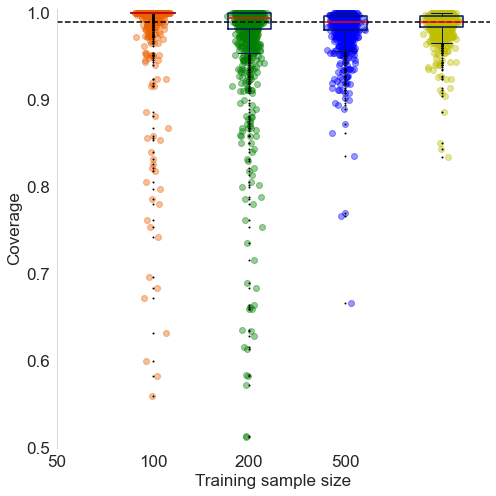

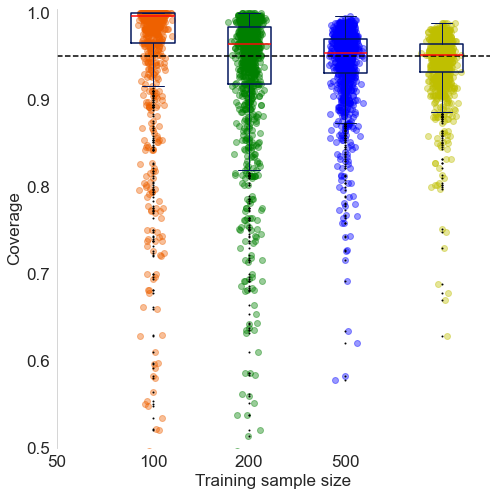

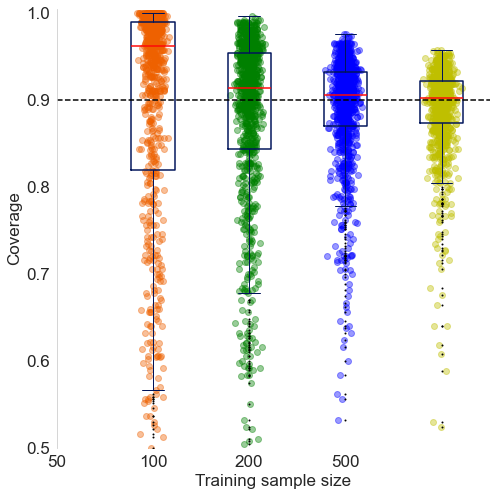

In [6]:
# Plot coverages vs. training sample size

# Only for AI

##### Set style options here #####
sns.set_style("whitegrid")  # "white","dark","darkgrid","ticks"
boxprops = dict(linestyle='-', linewidth=1.5, color='#00145A')
flierprops = dict(marker='o', markersize=1,
                  linestyle='none')
whiskerprops = dict(color='#00145A')
capprops = dict(color='#00145A')
medianprops = dict(linewidth=1.5, linestyle='-', color='#ff0808')

train_sizes = [50, 100, 200, 500]

for data, alpha_level in zip([iv_pb_coverage_df_alpha_01, iv_pb_coverage_df_alpha_05, iv_pb_coverage_df_alpha_1], [0.01, 0.05, 0.1]):
    fig = plt.figure(facecolor="white", figsize=(7, 7))
    ax = fig.add_subplot(111)

    #Note: when simulations are finalized, tehre should not be any need to select the first 40 (it is done because colukn had different lengths)
    data_50 = data[data['train_size'] == 50]
    data_100 = data[data['train_size'] == 100]
    data_200 = data[data['train_size'] == 200]
    data_500 = data[data['train_size'] == 500]

    boxplot_data = pd.DataFrame({
        '50': data_50['IV_coverage'].values,
        '100': data_100['IV_coverage'].values,
        '200': data_200['IV_coverage'].values,
        '500': data_500['IV_coverage'].values
    })

    #sns.boxplot(data = data, x='train_size', y='IV_coverage',
               # flierprops={"marker": "x"}, dodge=True, showmeans=True, meanprops={'marker':'o','markerfacecolor':'white','markeredgecolor':'white','markersize':'4'})
    ax.boxplot(boxplot_data, labels = ['50', '100', '200', '500'], notch=False, boxprops=boxprops, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False) 
    vals, names, xs = [],[],[]
    for i, col in enumerate(boxplot_data.columns):
        vals.append(boxplot_data[col].values)
        names.append(col)
        xs.append(np.random.normal(i + 1, 0.06, boxplot_data[col].values.shape[0]))  # adds jitter to the data points - can be adjusted
    palette = ['#ee6100', 'g', 'b', 'y']
    for x, val, c in zip(xs, vals, palette):
        ax.scatter(x, val, alpha=0.4, color=c)
    sns.despine(bottom=True)  # Remove right and top axis lines

    ax.set_xticks(range(len(train_sizes)))
    ax.set_xticklabels([str(size) for size in train_sizes], fontsize=17)
    if alpha_level == 0.01:
        ax.set_ylim(0.5, 1.005)
    elif alpha_level == 0.05:
        ax.set_ylim(0.5, 1.005)
    else:
        ax.set_ylim(0.5, 1.005)
    ax.set_xlabel('Training sample size', fontsize=17)
    ax.set_ylabel('Coverage', fontsize=17)
    ax.tick_params(labelsize=17)
    ax.axhline(y=1-alpha_level, color='black', linestyle='dashed')
    ax.grid(False)

    # Legend
    # Custom legend
    legend_handles = [
        mlines.Line2D([], [], color='gray', marker='o', linestyle='none', markersize=10, label='Prediction balls'),
        mlines.Line2D([], [], color='gray', marker='^', linestyle='none', markersize=10, label='SC')
    ]
 
    fig.tight_layout()
    filename = os.path.join(os.getcwd(), f'simulations_sphere/pb_kappa_IV_coverage_{str(alpha_level)[2:]}.pdf')
    fig.savefig(filename, bbox_inches='tight', format='pdf', transparent=True)